In [3]:
xgb_model = joblib.load("../models/xgboost_model.pkl")
preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model and preprocessor loaded successfully!")

Model and preprocessor loaded successfully!


In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/data.csv", sep=";")

df = df[df["Target"].isin(["Dropout", "Graduate"])].copy()

df["academic_risk"] = df["Target"].map({
    "Dropout": 1,
    "Graduate": 0
})

df.drop(columns=["Target"], inplace=True)

second_sem_columns = [
    col for col in df.columns
    if "2nd sem" in col
]

df.drop(columns=second_sem_columns, inplace=True)

X = df.drop(columns=["academic_risk"])
y = df["academic_risk"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
X_test_processed = preprocessor.transform(X_test)

print("Processed test shape:", X_test_processed.shape)

Processed test shape: (726, 30)


In [7]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_processed)

print("SHAP values generated!")

SHAP values generated!


In [8]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 30


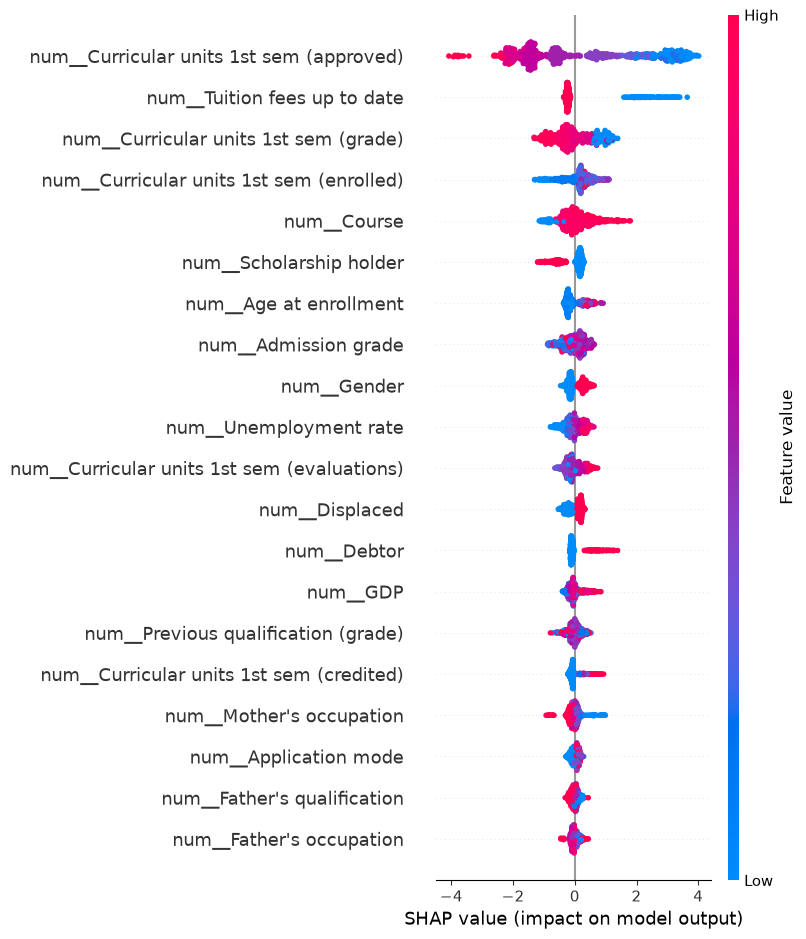

In [9]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

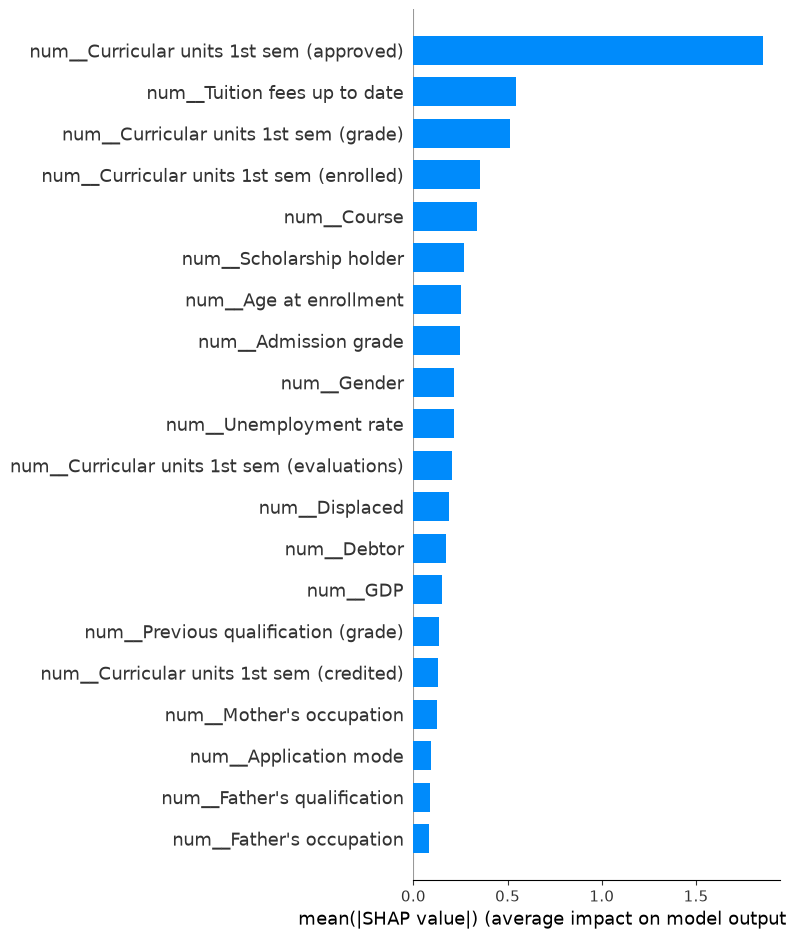

In [10]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

In [11]:
student_index = 0

student_data = X_test_processed[student_index]
student_shap = shap_values[student_index]

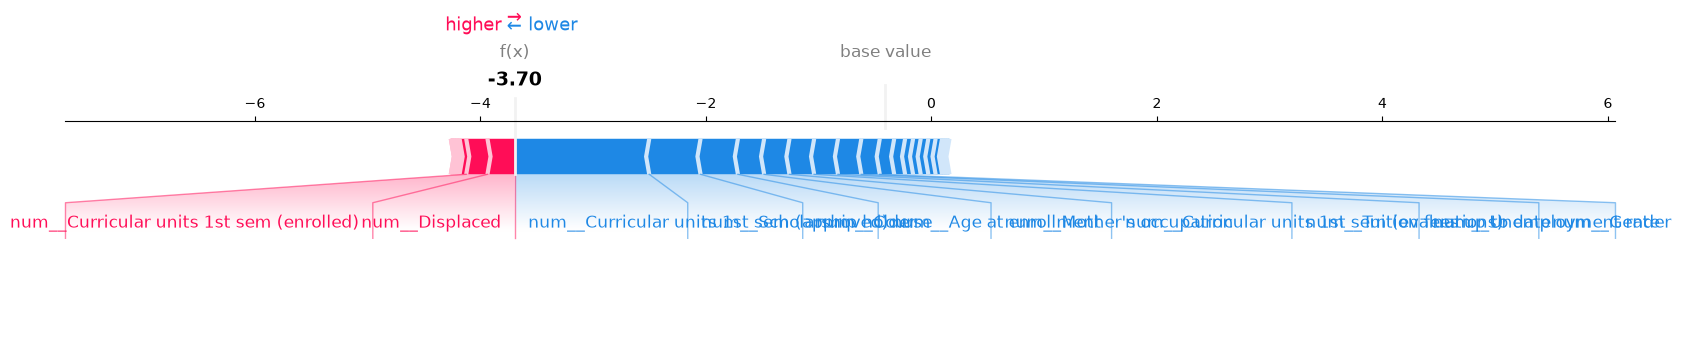

In [12]:
shap.force_plot(
    explainer.expected_value,
    student_shap,
    feature_names=feature_names,
    matplotlib=True
)

plt.show()

In [13]:
student_index = 0

student_data = X_test_processed[student_index]
student_shap = shap_values[student_index]

print("Actual outcome:", y_test.iloc[student_index])
print(
    "Predicted probability:",
    xgb_model.predict_proba(
        X_test_processed[student_index].reshape(1, -1)
    )[0][1]
)

Actual outcome: 0
Predicted probability: 0.024225662


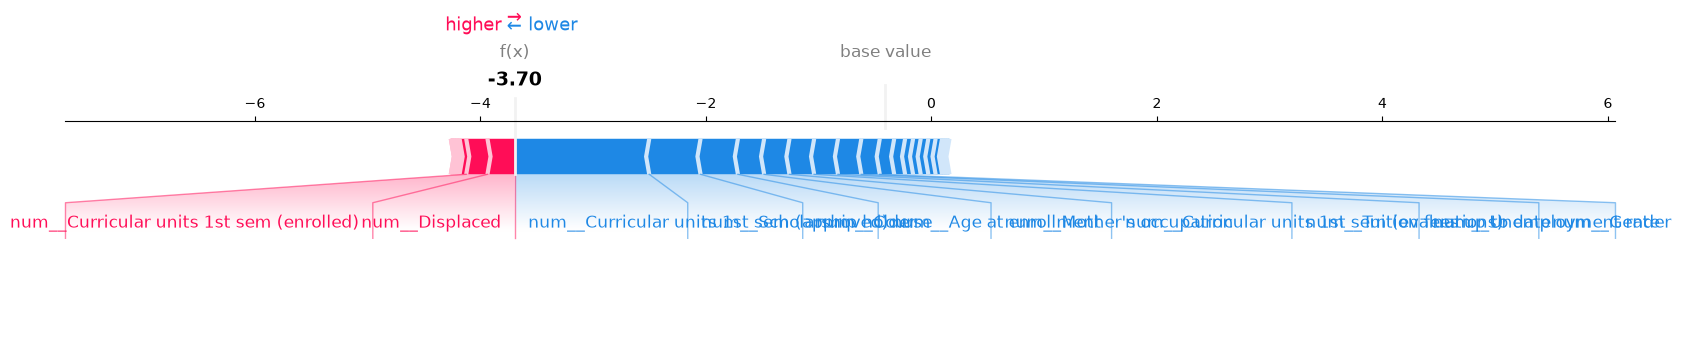

In [14]:
shap.force_plot(
    explainer.expected_value,
    student_shap,
    feature_names=feature_names,
    matplotlib=True
)

plt.show()

In [15]:
student_data = X_test_processed[student_index]

if hasattr(student_data, "toarray"):
    student_data = student_data.toarray()

student_data = np.asarray(student_data).reshape(1, -1)

probability = xgb_model.predict_proba(student_data)[0][1]

print("Predicted risk probability:", round(probability, 4))

Predicted risk probability: 0.0242


In [16]:
student_index = 0

student_data = X_test_processed[student_index]

if hasattr(student_data, "toarray"):
    student_data = student_data.toarray()

student_data = np.asarray(student_data).reshape(1, -1)

risk_probability = xgb_model.predict_proba(student_data)[0][1]

prediction = xgb_model.predict(student_data)[0]

print("Predicted Risk Probability:", round(risk_probability * 100, 2), "%")
print("Prediction:", "AT RISK" if prediction == 1 else "NOT AT RISK")
print("Actual:", "AT RISK" if y_test.iloc[student_index] == 1 else "NOT AT RISK")

Predicted Risk Probability: 2.42 %
Prediction: NOT AT RISK
Actual: NOT AT RISK


In [17]:
student_shap = shap_values[student_index]

shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP Value": student_shap
})

shap_df["Absolute SHAP"] = shap_df["SHAP Value"].abs()

shap_df = shap_df.sort_values(
    "Absolute SHAP",
    ascending=False
)

display(shap_df.head(10))

,Feature,SHAP Value,Absolute SHAP
24,num__Curricular units 1st sem (approved),-1.192724,1.192724
18,num__Scholarship holder,-0.455196,0.455196
3,num__Course,-0.331437,0.331437
13,num__Displaced,0.241979,0.241979
19,num__Age at enrollment,-0.232627,0.232627
10,num__Mother's occupation,-0.224666,0.224666
23,num__Curricular units 1st sem (evaluations),-0.218822,0.218822
16,num__Tuition fees up to date,-0.211613,0.211613
27,num__Unemployment rate,-0.206859,0.206859
22,num__Curricular units 1st sem (enrolled),0.188576,0.188576


In [18]:
risk_factors = shap_df[
    shap_df["SHAP Value"] > 0
].head(5)

protective_factors = shap_df[
    shap_df["SHAP Value"] < 0
].sort_values(
    "SHAP Value"
).head(5)

print("Factors increasing predicted risk:")
display(risk_factors)

print("Factors decreasing predicted risk:")
display(protective_factors)

Factors increasing predicted risk:


,Feature,SHAP Value,Absolute SHAP
13,num__Displaced,0.241979,0.241979
22,num__Curricular units 1st sem (enrolled),0.188576,0.188576
25,num__Curricular units 1st sem (grade),0.058713,0.058713
12,num__Admission grade,0.026193,0.026193
5,num__Previous qualification,0.020079,0.020079


Factors decreasing predicted risk:


,Feature,SHAP Value,Absolute SHAP
24,num__Curricular units 1st sem (approved),-1.192724,1.192724
18,num__Scholarship holder,-0.455196,0.455196
3,num__Course,-0.331437,0.331437
19,num__Age at enrollment,-0.232627,0.232627
10,num__Mother's occupation,-0.224666,0.224666


In [19]:
student_explanation = {
    "risk_probability": round(risk_probability, 4),
    "prediction": int(prediction),
    "risk_factors": risk_factors[
        ["Feature", "SHAP Value"]
    ].to_dict("records"),
    "protective_factors": protective_factors[
        ["Feature", "SHAP Value"]
    ].to_dict("records")
}

student_explanation

{'risk_probability': np.float32(0.0242),
 'prediction': 0,
 'risk_factors': [{'Feature': 'num__Displaced',
   'SHAP Value': 0.24197933077812195},
  {'Feature': 'num__Curricular units 1st sem (enrolled)',
   'SHAP Value': 0.18857599794864655},
  {'Feature': 'num__Curricular units 1st sem (grade)',
   'SHAP Value': 0.05871308594942093},
  {'Feature': 'num__Admission grade', 'SHAP Value': 0.026192694902420044},
  {'Feature': 'num__Previous qualification',
   'SHAP Value': 0.0200787540525198}],
 'protective_factors': [{'Feature': 'num__Curricular units 1st sem (approved)',
   'SHAP Value': -1.192724347114563},
  {'Feature': 'num__Scholarship holder', 'SHAP Value': -0.4551955461502075},
  {'Feature': 'num__Course', 'SHAP Value': -0.3314371705055237},
  {'Feature': 'num__Age at enrollment', 'SHAP Value': -0.23262697458267212},
  {'Feature': "num__Mother's occupation", 'SHAP Value': -0.22466644644737244}]}

In [20]:
print("===== ASCENTRA STUDENT RISK EXPLANATION =====")

print(f"Risk Probability: {risk_probability * 100:.2f}%")

if prediction == 1:
    print("Risk Status: AT RISK")
else:
    print("Risk Status: NOT AT RISK")

print("\nTop Risk-Increasing Factors:")

for _, row in risk_factors.iterrows():
    print(
        f"- {row['Feature']}: "
        f"{row['SHAP Value']:.3f}"
    )

print("\nTop Risk-Reducing Factors:")

for _, row in protective_factors.iterrows():
    print(
        f"- {row['Feature']}: "
        f"{row['SHAP Value']:.3f}"
    )

===== ASCENTRA STUDENT RISK EXPLANATION =====
Risk Probability: 2.42%
Risk Status: NOT AT RISK

Top Risk-Increasing Factors:
- num__Displaced: 0.242
- num__Curricular units 1st sem (enrolled): 0.189
- num__Curricular units 1st sem (grade): 0.059
- num__Admission grade: 0.026
- num__Previous qualification: 0.020

Top Risk-Reducing Factors:
- num__Curricular units 1st sem (approved): -1.193
- num__Scholarship holder: -0.455
- num__Course: -0.331
- num__Age at enrollment: -0.233
- num__Mother's occupation: -0.225
